In [1]:
import os
import math
import warnings
import holidays
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler

In [3]:
!pip install holidays

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **Load Dataset**

In [2]:
df = pd.read_csv('hybrid_traffic_7d.csv')
df.head()

,timestamp_wib,tick,intersectionId,approach,vehicle_count_1min,volume_veh_per_hour,avg_speed_kmh,queue_length_veh,wait_time_min,green_seconds,density_percent,weather_condition,weather_temp_c,accident_count,roadwork_flag,event_flag,target_volume_15m,target_volume_2h,target_volume_4h
0,2026-05-01T00:00:00+07:00,0,JKT-TMG-SIM-01,N,10,598.77,55.15,0,0.0,34,0.00,Cloudy,29.7,0,0,0,453.48,781.37,398.87
1,2026-05-01T00:00:00+07:00,0,JKT-TMG-SIM-01,E,0,0.00,57.74,0,0.0,20,0.00,Cloudy,29.7,0,0,0,395.93,397.61,640.25
2,2026-05-01T00:00:00+07:00,0,JKT-TMG-SIM-01,S,11,638.17,52.43,0,0.0,37,0.06,Cloudy,29.7,0,0,0,548.08,358.41,164.98
3,2026-05-01T00:00:00+07:00,0,JKT-TMG-SIM-01,W,6,333.01,52.50,0,0.0,20,0.00,Cloudy,29.7,0,0,0,351.34,302.14,305.34
4,2026-05-01T00:01:00+07:00,1,JKT-TMG-SIM-01,N,9,563.60,54.09,0,0.0,33,0.03,Cloudy,29.8,0,0,0,495.46,701.63,590.70


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40320 entries, 0 to 40319
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp_wib        40320 non-null  object 
 1   tick                 40320 non-null  int64  
 2   intersectionId       40320 non-null  object 
 3   approach             40320 non-null  object 
 4   vehicle_count_1min   40320 non-null  int64  
 5   volume_veh_per_hour  40320 non-null  float64
 6   avg_speed_kmh        40320 non-null  float64
 7   queue_length_veh     40320 non-null  int64  
 8   wait_time_min        40320 non-null  float64
 9   green_seconds        40320 non-null  int64  
 10  density_percent      40320 non-null  float64
 11  weather_condition    40320 non-null  object 
 12  weather_temp_c       40320 non-null  float64
 13  accident_count       40320 non-null  int64  
 14  roadwork_flag        40320 non-null  int64  
 15  event_flag           40320 non-null 

# **Handling Missing Values & Duplicates**

In [4]:
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0] if missing_info.sum() > 0 else "Tidak ada missing values")

Tidak ada missing values


In [5]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris data yang duplikat: {duplicate_count} baris")

if duplicate_count > 0:
    df = df.drop_duplicates(keep='first')
    print("Data duplikat telah berhasil dibersihkan.")

Jumlah baris data yang duplikat: 0 baris


# **Sinkronisasi Temporal & Lokasi**

In [6]:
df['timestamp_wib'] = pd.to_datetime(df['timestamp_wib'])

In [7]:
# Mengubah ID persimpangan dummy menjadi Simpang Susun Tomang
df['intersectionId'] = df['intersectionId'].replace({'JKT-TMG-SIM-01': 'TMG-1012'})

df = df.sort_values('timestamp_wib').reset_index(drop=True) # penting untuk LSTM

print("Tipe data kolom 'timestamp_wib' sekarang:", df['timestamp_wib'].dtype)
df[['timestamp_wib', 'intersectionId', 'vehicle_count_1min']].head()

Tipe data kolom 'timestamp_wib' sekarang: datetime64[ns, UTC+07:00]


,timestamp_wib,intersectionId,vehicle_count_1min
0,2026-05-01 00:00:00+07:00,TMG-1012,10
1,2026-05-01 00:00:00+07:00,TMG-1012,0
2,2026-05-01 00:00:00+07:00,TMG-1012,11
3,2026-05-01 00:00:00+07:00,TMG-1012,6
4,2026-05-01 00:01:00+07:00,TMG-1012,9


# **Data Validation & Consistency Check**

In [8]:
error_found = False

if (df['avg_speed_kmh'] < 0).any():
    print("[ERROR] Ditemukan kecepatan negatif.")
    error_found = True

if (df['queue_length_veh'] < 0).any():
    print("[ERROR] Ditemukan queue kendaraan negatif.")
    error_found = True

if (df['green_seconds'] <= 0).any():
    print("[ERROR] Ditemukan green light duration tidak valid.")
    error_found = True

if (df['vehicle_count_1min'] < 0).any():
    print("[ERROR] Ditemukan volume kendaraan negatif.")
    error_found = True

if ((df['density_percent'] < 0) | (df['density_percent'] > 100)).any():
    print("[ERROR] Density berada di luar rentang 0–100%.")
    error_found = True

if not error_found:
    print("[SUCCESS] Semua validasi data lalu lintas berhasil.")

[SUCCESS] Semua validasi data lalu lintas berhasil.


# **Feature Engineering**

In [9]:
# Buat dataset kalender 2026
calendar_dates = pd.date_range('2026-01-01', '2026-12-31')
id_holidays = holidays.ID(years=[2026])
calendar_df = pd.DataFrame({'date': calendar_dates})

# Buat fitur temporal
calendar_df['is_holiday'] = (calendar_df['date'].dt.date.isin(id_holidays).astype(int))
calendar_df['day_name'] = calendar_df['date'].dt.day_name()
calendar_df['is_weekend'] = (calendar_df['date'].dt.weekday >= 5).astype(int)

calendar_df['date_only'] = calendar_df['date'].dt.date

print('[INFO] Dataset kalender 2026 berhasil dibentuk.')
calendar_df.head()

[INFO] Dataset kalender 2026 berhasil dibentuk.


,date,is_holiday,day_name,is_weekend,date_only
0,2026-01-01,1,Thursday,0,2026-01-01
1,2026-01-02,0,Friday,0,2026-01-02
2,2026-01-03,0,Saturday,1,2026-01-03
3,2026-01-04,0,Sunday,1,2026-01-04
4,2026-01-05,0,Monday,0,2026-01-05


In [10]:
# SINKRONISASI DATA LALU LINTAS DENGAN DATA KALENDER #
# Buat kolom kunci 'date_only' di dataframe lalu lintas 
df['date_only'] = pd.to_datetime(df['timestamp_wib']).dt.date
merged_df = pd.merge(df, calendar_df[['date_only', 'is_holiday', 'is_weekend', 'day_name']], on='date_only', how='left')

merged_df = merged_df.sort_values(by='timestamp_wib').reset_index(drop=True)
merged_df['timestamp_wib'] = pd.to_datetime(merged_df['timestamp_wib'])

# FEATURE ENGINEERING TEMPORAL #
merged_df['hour'] = merged_df['timestamp_wib'].dt.hour
merged_df['day'] = merged_df['timestamp_wib'].dt.day
merged_df['day_of_week'] = merged_df['timestamp_wib'].dt.weekday
merged_df['month'] = merged_df['timestamp_wib'].dt.month

# CYCLICAL ENCODING # -> Waktu bersifat siklis
merged_df['hour_sin'] = np.sin(2 * np.pi * merged_df['hour'] / 24)
merged_df['hour_cos'] = np.cos(2 * np.pi * merged_df['hour'] / 24)

# ONE-HOT ENCODING APPROACH #
merged_df = pd.get_dummies(merged_df, columns=['approach'], drop_first=False)


print("[INFO] Sinkronisasi temporal dan feature engineering berhasil dilakukan.")
print(f"Dimensi dataset setelah feature engineering: {merged_df.shape}")
print("\nDaftar kolom dataset terbaru:")
print(merged_df.columns.tolist())
merged_df.head(10)

[INFO] Sinkronisasi temporal dan feature engineering berhasil dilakukan.
Dimensi dataset setelah feature engineering: (40320, 32)

Daftar kolom dataset terbaru:
['timestamp_wib', 'tick', 'intersectionId', 'vehicle_count_1min', 'volume_veh_per_hour', 'avg_speed_kmh', 'queue_length_veh', 'wait_time_min', 'green_seconds', 'density_percent', 'weather_condition', 'weather_temp_c', 'accident_count', 'roadwork_flag', 'event_flag', 'target_volume_15m', 'target_volume_2h', 'target_volume_4h', 'date_only', 'is_holiday', 'is_weekend', 'day_name', 'hour', 'day', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'approach_E', 'approach_N', 'approach_S', 'approach_W']


,timestamp_wib,tick,intersectionId,vehicle_count_1min,volume_veh_per_hour,avg_speed_kmh,queue_length_veh,wait_time_min,green_seconds,density_percent,...,hour,day,day_of_week,month,hour_sin,hour_cos,approach_E,approach_N,approach_S,approach_W
0,2026-05-01 00:00:00+07:00,0,TMG-1012,10,598.77,55.15,0,0.0,34,0.00,...,0,1,4,5,0.0,1.0,False,True,False,False
1,2026-05-01 00:00:00+07:00,0,TMG-1012,0,0.00,57.74,0,0.0,20,0.00,...,0,1,4,5,0.0,1.0,True,False,False,False
2,2026-05-01 00:00:00+07:00,0,TMG-1012,11,638.17,52.43,0,0.0,37,0.06,...,0,1,4,5,0.0,1.0,False,False,True,False
3,2026-05-01 00:00:00+07:00,0,TMG-1012,6,333.01,52.50,0,0.0,20,0.00,...,0,1,4,5,0.0,1.0,False,False,False,True
4,2026-05-01 00:01:00+07:00,1,TMG-1012,9,563.60,54.09,0,0.0,33,0.03,...,0,1,4,5,0.0,1.0,False,True,False,False
5,2026-05-01 00:01:00+07:00,1,TMG-1012,0,6.63,56.47,0,0.0,20,0.56,...,0,1,4,5,0.0,1.0,True,False,False,False
6,2026-05-01 00:01:00+07:00,1,TMG-1012,11,660.07,51.58,0,0.0,38,0.23,...,0,1,4,5,0.0,1.0,False,False,True,False
7,2026-05-01 00:01:00+07:00,1,TMG-1012,5,325.89,52.08,0,0.0,20,0.00,...,0,1,4,5,0.0,1.0,False,False,False,True
8,2026-05-01 00:02:00+07:00,2,TMG-1012,0,0.00,58.44,0,0.0,20,0.00,...,0,1,4,5,0.0,1.0,True,False,False,False
9,2026-05-01 00:02:00+07:00,2,TMG-1012,10,605.78,53.01,0,0.0,35,0.00,...,0,1,4,5,0.0,1.0,False,True,False,False


In [11]:
# LAG FEATURE ENGINEERING # -> Memahami kondisi masa lalu (5 menit sebelumnya)
merged_df['lag_volume_5'] = (merged_df['vehicle_count_1min'].shift(5))
merged_df['lag_speed_5'] = (merged_df['avg_speed_kmh'].shift(5))
merged_df['lag_queue_5'] = (merged_df['queue_length_veh'].shift(5))

print("[INFO] Lag feature berhasil dibuat.")

kolom_lag = [
    'vehicle_count_1min',
    'lag_volume_5',
    'avg_speed_kmh',
    'lag_speed_5',
    'queue_length_veh',
    'lag_queue_5'
]

merged_df[kolom_lag].head(10)

[INFO] Lag feature berhasil dibuat.


,vehicle_count_1min,lag_volume_5,avg_speed_kmh,lag_speed_5,queue_length_veh,lag_queue_5
0,10,NaN,55.15,NaN,0,NaN
1,0,NaN,57.74,NaN,0,NaN
2,11,NaN,52.43,NaN,0,NaN
3,6,NaN,52.50,NaN,0,NaN
4,9,NaN,54.09,NaN,0,NaN
5,0,10.0,56.47,55.15,0,0.0
6,11,0.0,51.58,57.74,0,0.0
7,5,11.0,52.08,52.43,0,0.0
8,0,6.0,58.44,52.50,0,0.0
9,10,9.0,53.01,54.09,0,0.0


In [12]:
# ROLLING WINDOW FEATURE ENGINEERING # -> Membaca tren lalu lintas
# Rata-rata volume kendaraan 15 menit terakhir
merged_df['rolling_volume_15m'] = (
    merged_df['vehicle_count_1min']
    .rolling(window=15)
    .mean()
)

# Rata-rata kecepatan kendaraan 15 menit terakhir
merged_df['rolling_speed_15m'] = (
    merged_df['avg_speed_kmh']
    .rolling(window=15)
    .mean()
)

# Rata-rata antrean kendaraan 15 menit terakhir
merged_df['rolling_queue_15m'] = (
    merged_df['queue_length_veh']
    .rolling(window=15)
    .mean()
)

print("[INFO] Rolling window feature berhasil dibuat.")

kolom_rolling = [
    'vehicle_count_1min',
    'rolling_volume_15m',
    'avg_speed_kmh',
    'rolling_speed_15m',
    'queue_length_veh',
    'rolling_queue_15m'
]

merged_df[kolom_rolling].head(20)

[INFO] Rolling window feature berhasil dibuat.


,vehicle_count_1min,rolling_volume_15m,avg_speed_kmh,rolling_speed_15m,queue_length_veh,rolling_queue_15m
0,10,NaN,55.15,NaN,0,NaN
1,0,NaN,57.74,NaN,0,NaN
2,11,NaN,52.43,NaN,0,NaN
3,6,NaN,52.50,NaN,0,NaN
4,9,NaN,54.09,NaN,0,NaN
5,0,NaN,56.47,NaN,0,NaN
6,11,NaN,51.58,NaN,0,NaN
7,5,NaN,52.08,NaN,0,NaN
8,0,NaN,58.44,NaN,0,NaN
9,10,NaN,53.01,NaN,0,NaN


In [13]:
# TRAFFIC CONTEXT & CONGESTION CLASSIFICATION # -> Dashboard
# Klasifikasi periode lalu lintas
def classify_traffic_period(hour):
    if 6 <= hour < 10:
        return 'Morning Rush'
    elif 16 <= hour < 20:
        return 'Evening Rush'
    elif 0 <= hour < 5:
        return 'Late Night'
    return 'Normal'

merged_df['traffic_period'] = (merged_df['hour'].apply(classify_traffic_period))

# Klasifikasi tingkat kemacetan
def classify_congestion(density):
    if density < 30:
        return 'Free Flow'
    elif density < 60:
        return 'Moderate'
    elif density < 80:
        return 'Heavy'
    return 'Gridlock'

merged_df['congestion_level'] = (merged_df['density_percent'].apply(classify_congestion))

print("[INFO] Traffic context feature berhasil dibuat.")

merged_df[
    [
        'hour',
        'traffic_period',
        'density_percent',
        'congestion_level'
    ]
].head(20)

[INFO] Traffic context feature berhasil dibuat.


,hour,traffic_period,density_percent,congestion_level
0,0,Late Night,0.00,Free Flow
1,0,Late Night,0.00,Free Flow
2,0,Late Night,0.06,Free Flow
3,0,Late Night,0.00,Free Flow
4,0,Late Night,0.03,Free Flow
5,0,Late Night,0.56,Free Flow
6,0,Late Night,0.23,Free Flow
7,0,Late Night,0.00,Free Flow
8,0,Late Night,0.00,Free Flow
9,0,Late Night,0.00,Free Flow


In [14]:
# HANDLING MISSING VALUE AFTER FEATURE ENGINEERING #
print("Jumlah missing value sebelum cleaning:")
print(merged_df.isnull().sum()[merged_df.isnull().sum() > 0])

# Hapus missing value akibat lag & rolling
merged_df = merged_df.dropna().reset_index(drop=True)

print("\n[SUCCESS] Missing value akibat feature engineering berhasil dibersihkan.")


# VERIFIKASI HASIL CLEANING #
print("\nJumlah missing value setelah cleaning:")
print(merged_df.isnull().sum().sum())
print(f"\nDimensi dataset terbaru: {merged_df.shape}")
merged_df.head()

Jumlah missing value sebelum cleaning:
lag_volume_5           5
lag_speed_5            5
lag_queue_5            5
rolling_volume_15m    14
rolling_speed_15m     14
rolling_queue_15m     14
dtype: int64

[SUCCESS] Missing value akibat feature engineering berhasil dibersihkan.

Jumlah missing value setelah cleaning:
0

Dimensi dataset terbaru: (40306, 40)


,timestamp_wib,tick,intersectionId,vehicle_count_1min,volume_veh_per_hour,avg_speed_kmh,queue_length_veh,wait_time_min,green_seconds,density_percent,...,approach_S,approach_W,lag_volume_5,lag_speed_5,lag_queue_5,rolling_volume_15m,rolling_speed_15m,rolling_queue_15m,traffic_period,congestion_level
0,2026-05-01 00:03:00+07:00,3,TMG-1012,9,518.59,55.65,0,0.0,29,0.21,...,False,False,10.0,53.01,0.0,6.800000,54.252000,0.0,Late Night,Free Flow
1,2026-05-01 00:03:00+07:00,3,TMG-1012,3,195.53,58.23,0,0.0,20,0.22,...,False,False,5.0,52.71,0.0,6.333333,54.457333,0.0,Late Night,Free Flow
2,2026-05-01 00:04:00+07:00,4,TMG-1012,0,21.44,58.16,0,0.0,20,0.00,...,False,False,11.0,54.28,0.0,6.333333,54.485333,0.0,Late Night,Free Flow
3,2026-05-01 00:04:00+07:00,4,TMG-1012,8,509.41,54.96,0,0.0,31,0.00,...,False,False,10.0,53.96,0.0,6.133333,54.654000,0.0,Late Night,Free Flow
4,2026-05-01 00:04:00+07:00,4,TMG-1012,6,341.26,50.50,0,0.0,21,0.33,...,False,True,5.0,53.69,0.0,6.133333,54.520667,0.0,Late Night,Free Flow


In [15]:
# FINAL FEATURE ENGINEERING VERIFICATION #
print("[INFO] Final feature engineering verification selesai.")
print(f"\nDimensi akhir dataset: {merged_df.shape}")
print("\nDaftar seluruh kolom dataset:")
print(merged_df.columns.tolist())
print("\nPreview dataset akhir:")
merged_df.head(10)

[INFO] Final feature engineering verification selesai.

Dimensi akhir dataset: (40306, 40)

Daftar seluruh kolom dataset:
['timestamp_wib', 'tick', 'intersectionId', 'vehicle_count_1min', 'volume_veh_per_hour', 'avg_speed_kmh', 'queue_length_veh', 'wait_time_min', 'green_seconds', 'density_percent', 'weather_condition', 'weather_temp_c', 'accident_count', 'roadwork_flag', 'event_flag', 'target_volume_15m', 'target_volume_2h', 'target_volume_4h', 'date_only', 'is_holiday', 'is_weekend', 'day_name', 'hour', 'day', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'approach_E', 'approach_N', 'approach_S', 'approach_W', 'lag_volume_5', 'lag_speed_5', 'lag_queue_5', 'rolling_volume_15m', 'rolling_speed_15m', 'rolling_queue_15m', 'traffic_period', 'congestion_level']

Preview dataset akhir:


,timestamp_wib,tick,intersectionId,vehicle_count_1min,volume_veh_per_hour,avg_speed_kmh,queue_length_veh,wait_time_min,green_seconds,density_percent,...,approach_S,approach_W,lag_volume_5,lag_speed_5,lag_queue_5,rolling_volume_15m,rolling_speed_15m,rolling_queue_15m,traffic_period,congestion_level
0,2026-05-01 00:03:00+07:00,3,TMG-1012,9,518.59,55.65,0,0.0,29,0.21,...,False,False,10.0,53.01,0.0,6.800000,54.252000,0.0,Late Night,Free Flow
1,2026-05-01 00:03:00+07:00,3,TMG-1012,3,195.53,58.23,0,0.0,20,0.22,...,False,False,5.0,52.71,0.0,6.333333,54.457333,0.0,Late Night,Free Flow
2,2026-05-01 00:04:00+07:00,4,TMG-1012,0,21.44,58.16,0,0.0,20,0.00,...,False,False,11.0,54.28,0.0,6.333333,54.485333,0.0,Late Night,Free Flow
3,2026-05-01 00:04:00+07:00,4,TMG-1012,8,509.41,54.96,0,0.0,31,0.00,...,False,False,10.0,53.96,0.0,6.133333,54.654000,0.0,Late Night,Free Flow
4,2026-05-01 00:04:00+07:00,4,TMG-1012,6,341.26,50.50,0,0.0,21,0.33,...,False,True,5.0,53.69,0.0,6.133333,54.520667,0.0,Late Night,Free Flow
5,2026-05-01 00:04:00+07:00,4,TMG-1012,10,615.33,53.05,0,0.0,37,0.00,...,True,False,9.0,55.65,0.0,6.200000,54.451333,0.0,Late Night,Free Flow
6,2026-05-01 00:05:00+07:00,5,TMG-1012,11,646.74,53.49,0,0.0,31,0.06,...,False,False,3.0,58.23,0.0,6.933333,54.252667,0.0,Late Night,Free Flow
7,2026-05-01 00:05:00+07:00,5,TMG-1012,9,533.15,58.84,0,0.0,26,0.11,...,False,False,0.0,58.16,0.0,6.800000,54.736667,0.0,Late Night,Free Flow
8,2026-05-01 00:05:00+07:00,5,TMG-1012,7,397.69,52.74,0,0.0,20,0.44,...,True,False,8.0,54.96,0.0,6.933333,54.780667,0.0,Late Night,Free Flow
9,2026-05-01 00:05:00+07:00,5,TMG-1012,5,302.00,51.10,0,0.0,20,0.11,...,False,True,6.0,50.50,0.0,7.266667,54.291333,0.0,Late Night,Free Flow


# **Exploratory Data Analysis (EDA)**

In [16]:
%matplotlib inline
sns.set_theme(style="darkgrid")

In [17]:
# Statistik deskriptif fitur utama
fitur_utama = ['vehicle_count_1min', 'volume_veh_per_hour', 'avg_speed_kmh', 'queue_length_veh']
print("Statistik Deskriptif Fitur Lalu Lintas")
display(merged_df[fitur_utama].describe())

Statistik Deskriptif Fitur Lalu Lintas


,vehicle_count_1min,volume_veh_per_hour,avg_speed_kmh,queue_length_veh
count,40306.000000,40306.000000,40306.000000,40306.000000
mean,9.181660,550.983953,52.146628,7.222796
std,7.046995,422.379857,8.205562,43.129412
min,0.000000,0.000000,10.000000,0.000000
25%,5.000000,287.602500,51.030000,0.000000
50%,8.000000,456.155000,53.840000,0.000000
75%,12.000000,691.242500,56.250000,0.000000
max,84.000000,5037.880000,60.000000,628.000000


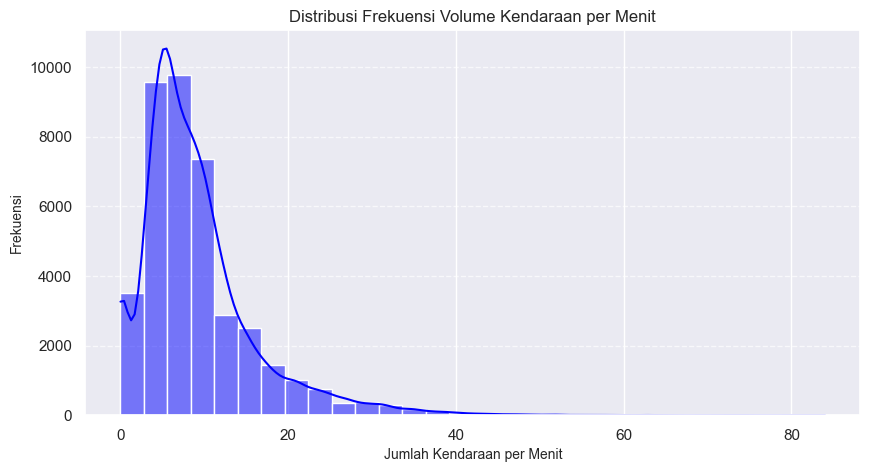

In [18]:
# DISTRIBUSI FREKUENSI VOLUME KENDARAAN #
# Melihat persebaran volume kendaraan per menit untuk mengetahui:
# - pola distribusi data
# - kemungkinan skewness
# - potensi outlier

plt.figure(figsize=(10, 5))
sns.histplot(df['vehicle_count_1min'], kde=True, bins=30, color='blue')
plt.title('Distribusi Frekuensi Volume Kendaraan per Menit', fontsize=12)
plt.xlabel('Jumlah Kendaraan per Menit', fontsize=10)
plt.ylabel('Frekuensi', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

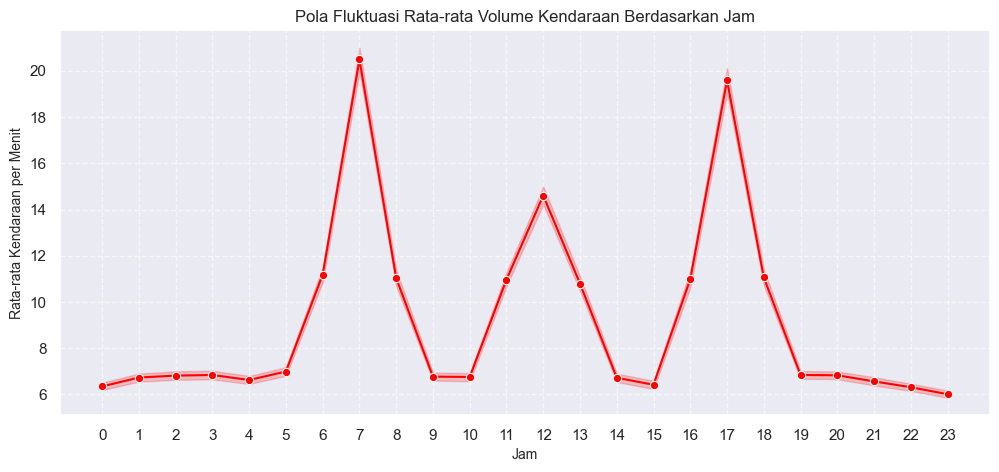

In [19]:
# POLA FLUKTUASI VOLUME BERDASARKAN JAM #
# Mengidentifikasi pola siklus harian lalu lintas seperti jam sibuk dan jam lengang
plt.figure(figsize=(12, 5))
sns.lineplot(data=merged_df, x='hour', y='vehicle_count_1min', estimator='mean', color='red', marker='o')
plt.title('Pola Fluktuasi Rata-rata Volume Kendaraan Berdasarkan Jam', fontsize=12)
plt.xlabel('Jam', fontsize=10)
plt.ylabel('Rata-rata Kendaraan per Menit', fontsize=10)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

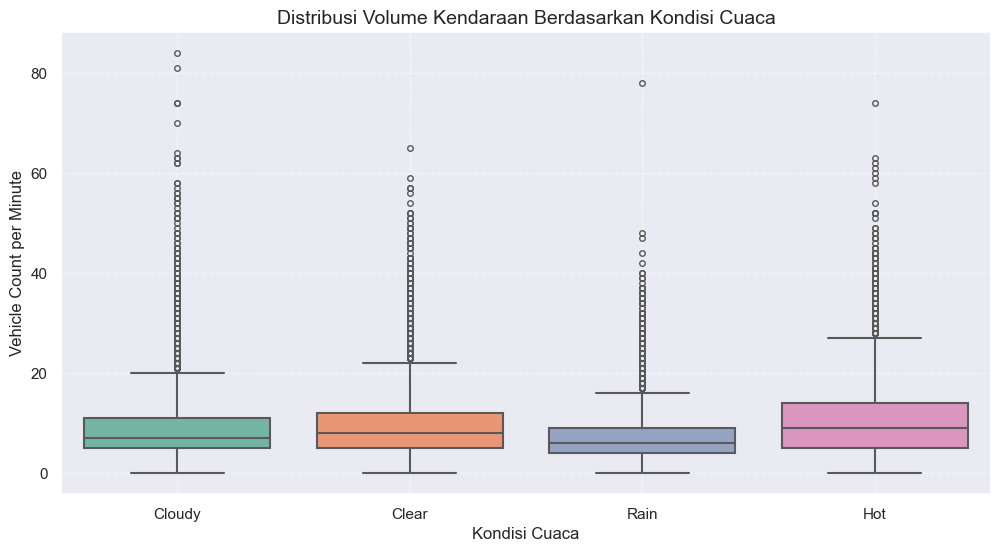

In [20]:
# DISTRIBUSI VOLUME BERDASARKAN KONDISI CUACA #
# Menganalisis pengaruh kondisi cuaca terhadap volume kendaraan dan aktivitas lalu lintas
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='weather_condition',
    y='vehicle_count_1min',
    data=merged_df,
    hue='weather_condition',
    legend=False,
    palette='Set2',
    linewidth=1.5,
    fliersize=4
)

plt.title('Distribusi Volume Kendaraan Berdasarkan Kondisi Cuaca', fontsize=14)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Vehicle Count per Minute')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

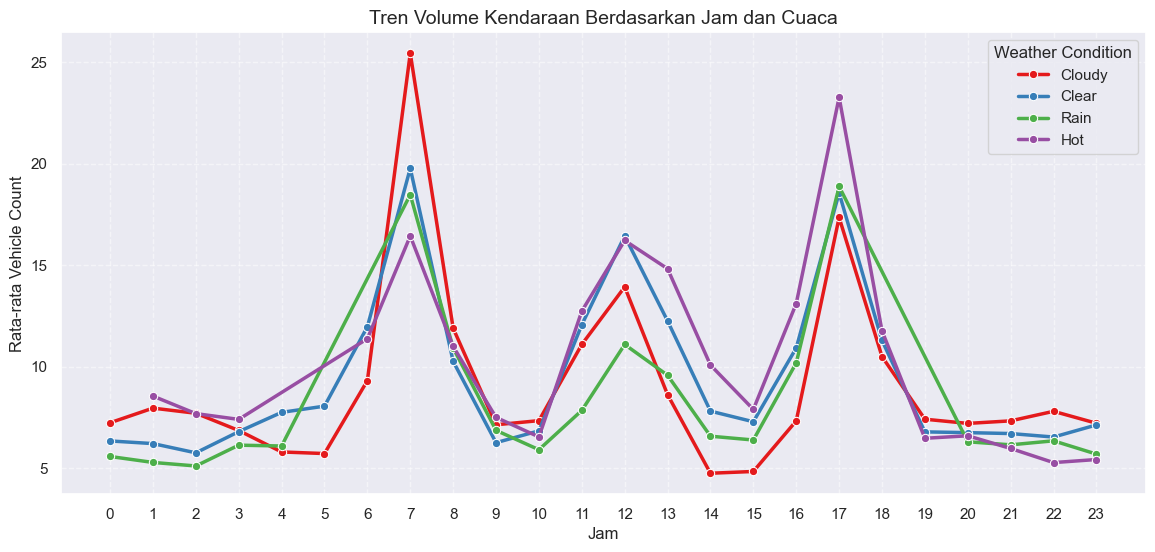

In [21]:
# TREN VOLUME BERDASARKAN JAM & CUACA #
# Melihat hubungan kombinasi antara waktu dan cuaca terhadap perubahan volume kendaraan
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=merged_df,
    x='hour',
    y='vehicle_count_1min',
    hue='weather_condition',
    estimator='mean',
    palette='Set1',
    marker='o',
    linewidth=2.5,
    errorbar=None  # Fokus pada garis tren rata-rata utama agar chart terlihat clean
)

plt.title('Tren Volume Kendaraan Berdasarkan Jam dan Cuaca', fontsize=14)
plt.xlabel('Jam')
plt.ylabel('Rata-rata Vehicle Count')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Weather Condition')
plt.show()

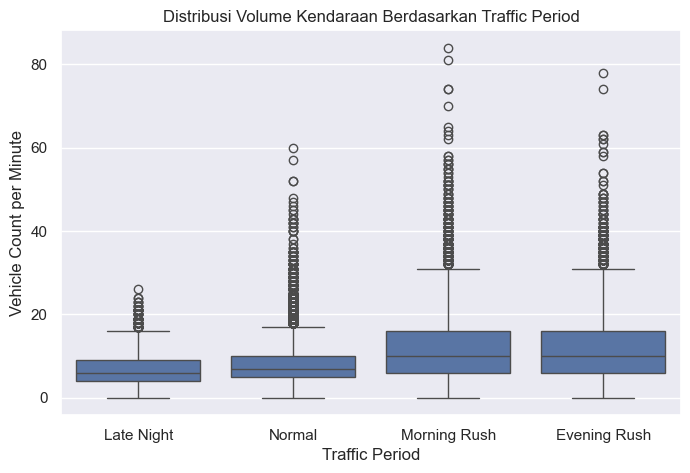

In [22]:
# ANALISIS TRAFFIC PERIOD #
# Membandingkan distribusi volume kendaraan untuk memvalidasi pola traffic simulator
plt.figure(figsize=(8,5))
sns.boxplot(data=merged_df, x='traffic_period', y='vehicle_count_1min')
plt.title('Distribusi Volume Kendaraan Berdasarkan Traffic Period')
plt.xlabel('Traffic Period')
plt.ylabel('Vehicle Count per Minute')
plt.show()

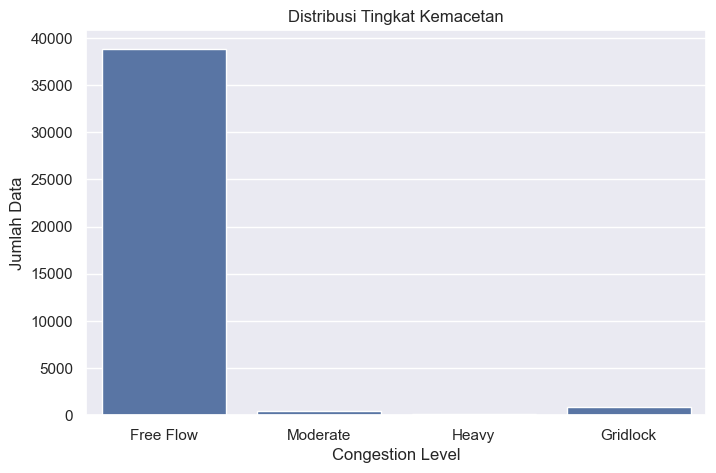

In [23]:
# ANALISIS CONGESTION LEVEL #
# Melihat distribusi tingkat kemacetan (terlalu macet, terlalu lancar, atau cukup seimbang)
plt.figure(figsize=(8,5))
sns.countplot(data=merged_df, x='congestion_level')
plt.title('Distribusi Tingkat Kemacetan')
plt.xlabel('Congestion Level')
plt.ylabel('Jumlah Data')
plt.show()

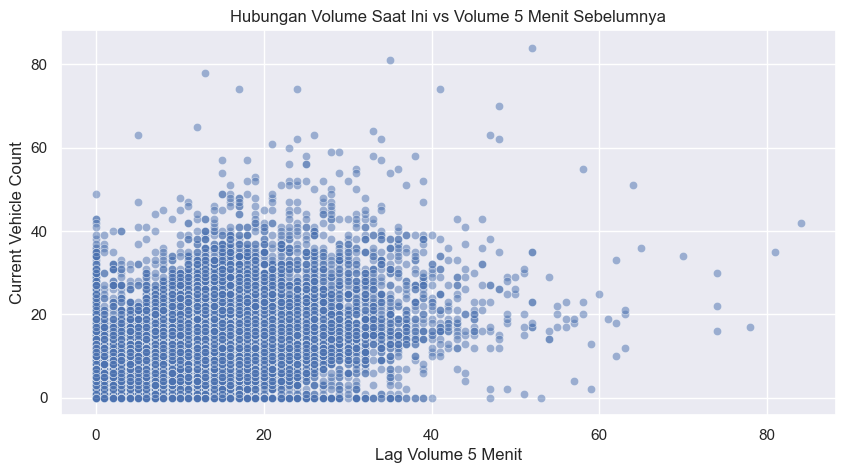

In [24]:
# ANALISIS HUBUNGAN LAG FEATURE #
# Memahami temporal dependency traffic
plt.figure(figsize=(10,5))
sns.scatterplot(data=merged_df, x='lag_volume_5', y='vehicle_count_1min', alpha=0.5)
plt.title('Hubungan Volume Saat Ini vs Volume 5 Menit Sebelumnya')
plt.xlabel('Lag Volume 5 Menit')
plt.ylabel('Current Vehicle Count')
plt.show()

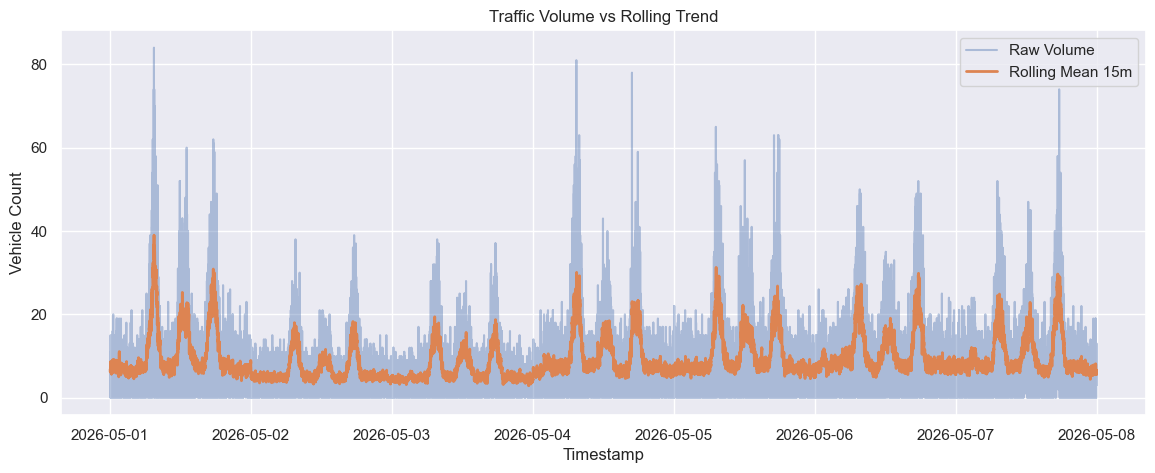

In [25]:
# ANALISIS ROLLING TREND #
# Membandingkan:
# - data volume asli
# - tren rata-rata rolling
# untuk melihat kestabilan pola lalu lintas
plt.figure(figsize=(14,5))
plt.plot(
    merged_df['timestamp_wib'],
    merged_df['vehicle_count_1min'],
    alpha=0.4,
    label='Raw Volume'
)

plt.plot(
    merged_df['timestamp_wib'],
    merged_df['rolling_volume_15m'],
    linewidth=2,
    label='Rolling Mean 15m'
)

plt.title('Traffic Volume vs Rolling Trend')
plt.xlabel('Timestamp')
plt.ylabel('Vehicle Count')
plt.legend()
plt.show()

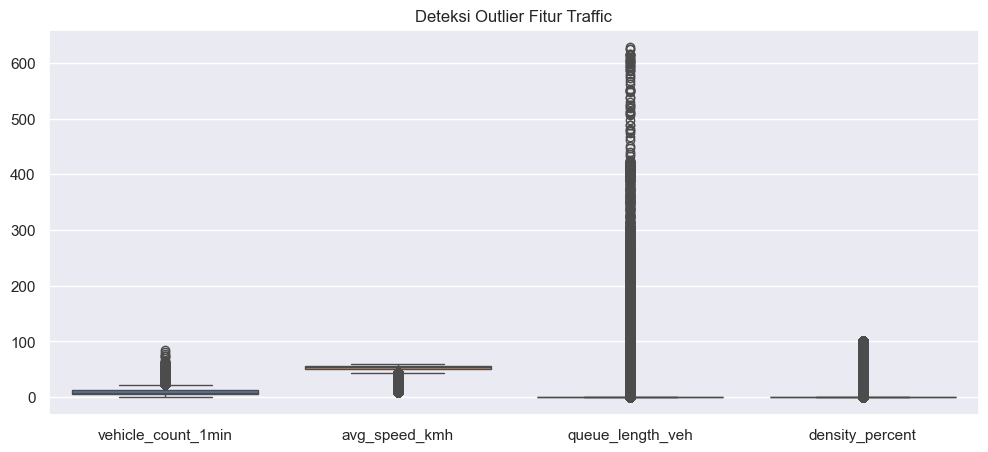

In [26]:
# DETEKSI OUTLIER FITUR TRAFFIC #
plt.figure(figsize=(12,5))
sns.boxplot(
    data=merged_df[
        [
            'vehicle_count_1min',
            'avg_speed_kmh',
            'queue_length_veh',
            'density_percent'
        ]
    ]
)

plt.title('Deteksi Outlier Fitur Traffic')
plt.show()

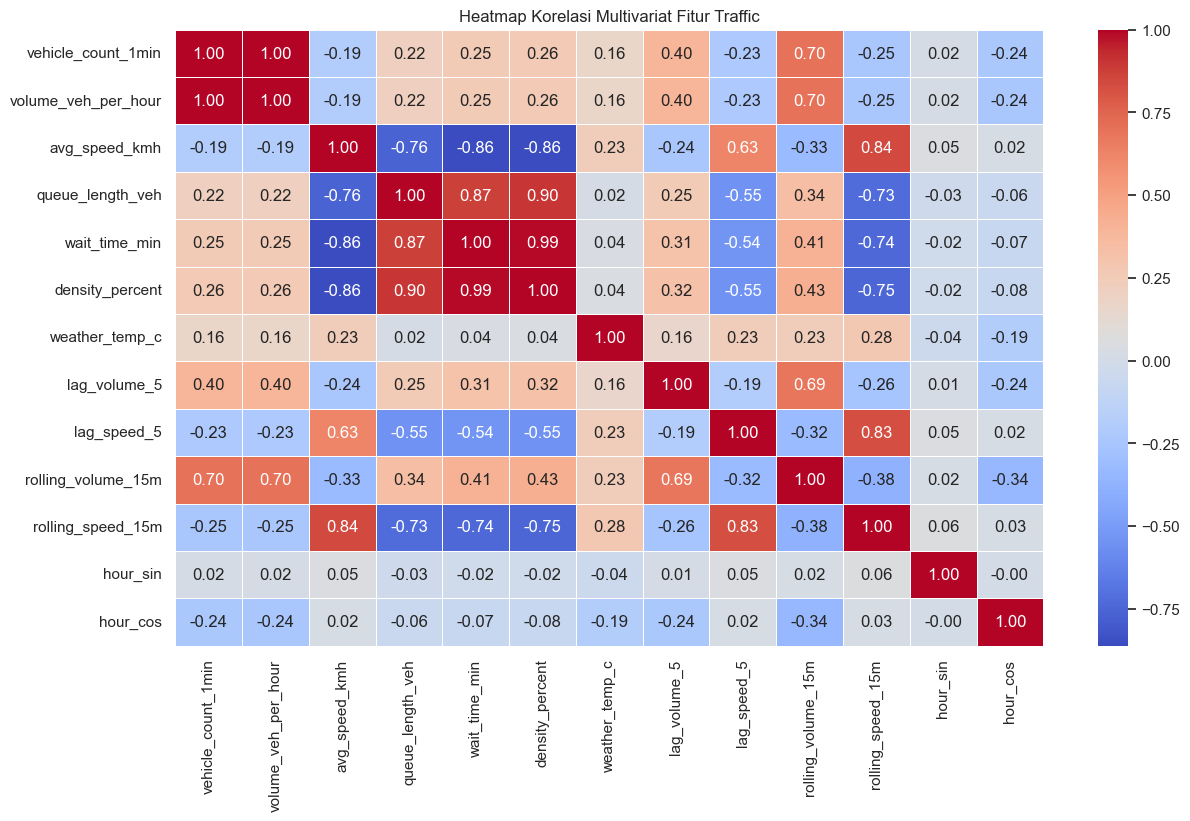

In [27]:
# HEATMAP KORELASI FITUR TRAFFIC #
# Melihat hubungan keterkaitan antar fitur numerik
fitur_numerik = [
    'vehicle_count_1min',
    'volume_veh_per_hour',
    'avg_speed_kmh',
    'queue_length_veh',
    'wait_time_min',
    'density_percent',
    'weather_temp_c',
    'lag_volume_5',
    'lag_speed_5',
    'rolling_volume_15m',
    'rolling_speed_15m',
    'hour_sin',
    'hour_cos'
]

plt.figure(figsize=(14,8))
sns.heatmap(merged_df[fitur_numerik].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Multivariat Fitur Traffic')
plt.show()

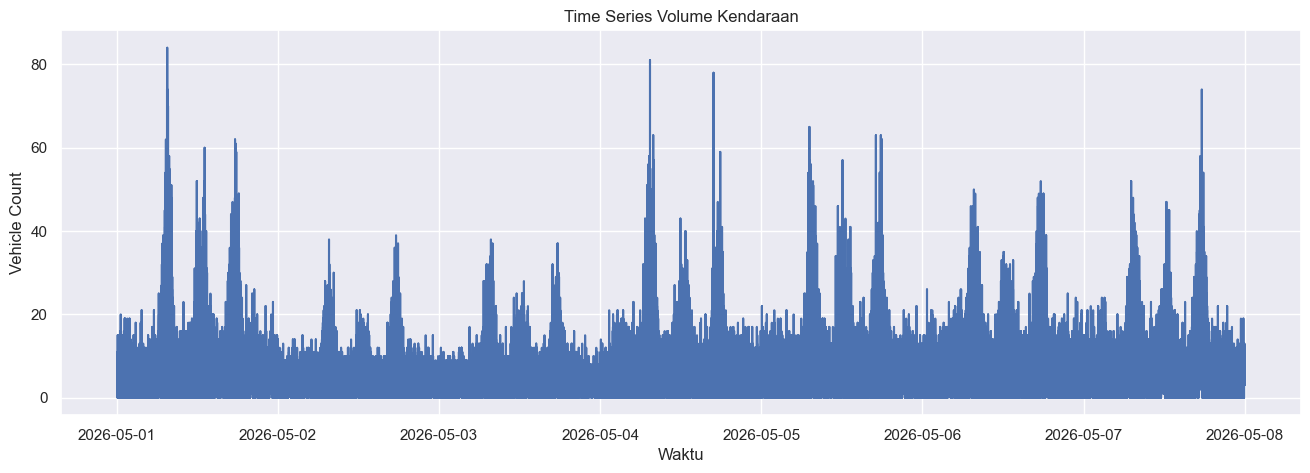

In [28]:
# TIME SERIES VISUALIZATION #
# Melihat pola perubahan volume kendaraan berdasarkan waktu untuk:
# - mendeteksi seasonality
# - melihat rush hour
# - melihat pola temporal
plt.figure(figsize=(16,5))
plt.plot(
    merged_df['timestamp_wib'],
    merged_df['vehicle_count_1min']
)

plt.title('Time Series Volume Kendaraan')
plt.xlabel('Waktu')
plt.ylabel('Vehicle Count')
plt.show()

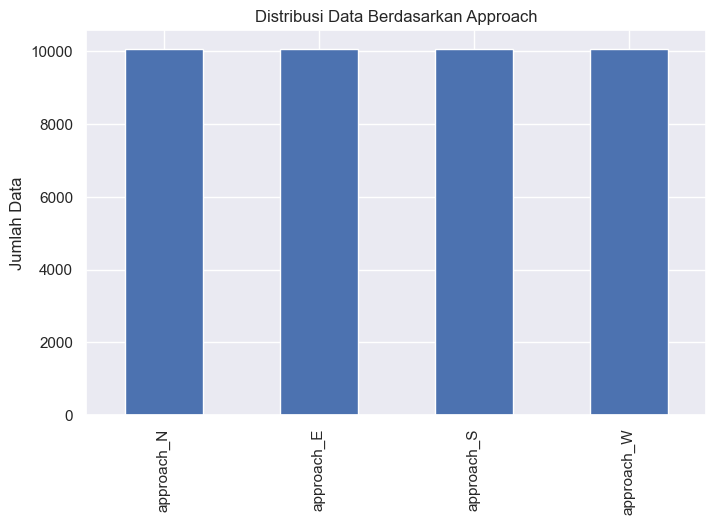

In [29]:
# ANALISIS DISTRIBUSI APPROACH #
approach_cols = [
    'approach_N',
    'approach_E',
    'approach_S',
    'approach_W'
]

merged_df[approach_cols].sum().plot(kind='bar', figsize=(8,5))
plt.title('Distribusi Data Berdasarkan Approach')
plt.ylabel('Jumlah Data')
plt.show()

# **Feature Scaling**

In [30]:
# Ubah fitur cuaca kategorikal menjadi numerik
merged_df = pd.get_dummies(merged_df, columns=['weather_condition'], drop_first=False)

# Mencegah error bila suatu kategori cuaca tidak muncul
weather_columns = [
    'weather_condition_Clear',
    'weather_condition_Cloudy',
    'weather_condition_Hot',
    'weather_condition_Rain'
]

merged_df = merged_df.reindex(
    columns=merged_df.columns.tolist() + [
        col for col in weather_columns
        if col not in merged_df.columns
    ],
    fill_value=0
)

# Daftar fitur numerik yang perlu scaling
fitur_numerik = [
    # Traffic utama
    'vehicle_count_1min', 'volume_veh_per_hour', 'avg_speed_kmh', 'queue_length_veh',
    'wait_time_min', 'green_seconds', 'density_percent', 'weather_temp_c',

    # Temporal feature
    'hour', 'day', 'day_of_week', 'month',

    # Cyclical encoding
    'hour_sin', 'hour_cos',

    # Lag feature
    'lag_volume_5', 'lag_speed_5', 'lag_queue_5',

    # Rolling feature
    'rolling_volume_15m', 'rolling_speed_15m', 'rolling_queue_15m'
]

# Daftar fitur binary/ encoded
fitur_binary = [
    # Event & incident
    'accident_count', 'roadwork_flag', 'event_flag',

    # Kalender
    'is_weekend', 'is_holiday',

    # Encoding approach
    'approach_E', 'approach_N', 'approach_S', 'approach_W',

    # Encoding cuaca
    'weather_condition_Clear', 'weather_condition_Cloudy', 'weather_condition_Hot', 'weather_condition_Rain'
]


fitur_input = fitur_numerik + fitur_binary

# Target output yang mau diramal (15 menit ke depan)
target_output = ['target_volume_15m']

X = merged_df[fitur_input].astype(float)
y = merged_df[target_output].astype(float)

print("VERIFIKASI DIMENSI DATA")
print(f"Dimensi Fitur Independen (X): {X.shape} Total: {X.shape[1]} Fitur")
print(f"Dimensi Target Dependen  (y): {y.shape}")

VERIFIKASI DIMENSI DATA
Dimensi Fitur Independen (X): (40306, 33) Total: 33 Fitur
Dimensi Target Dependen  (y): (40306, 1)


In [31]:
# TEMPORAL TRAIN-TEST SPLIT # -> Menghindari data leakage
# Temporal split tanpa random shuffle
split_index = int(len(merged_df) * 0.80)

# Pembagian untuk Fitur (X)
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

# Pembagian untuk Target (y)
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("HASIL PEMISAHAN DATA TEMPORAL")
print(f"Data Latih (X_train): {X_train.shape} | Data Uji (X_test): {X_test.shape}")
print(f"Rentang Waktu Train : {merged_df['timestamp_wib'].iloc[0]} s/d {merged_df['timestamp_wib'].iloc[split_index-1]}")
print(f"Rentang Waktu Test  : {merged_df['timestamp_wib'].iloc[split_index]} s/d {merged_df['timestamp_wib'].iloc[-1]}")

HASIL PEMISAHAN DATA TEMPORAL
Data Latih (X_train): (32244, 33) | Data Uji (X_test): (8062, 33)
Rentang Waktu Train : 2026-05-01 00:03:00+07:00 s/d 2026-05-06 14:24:00+07:00
Rentang Waktu Test  : 2026-05-06 14:24:00+07:00 s/d 2026-05-07 23:59:00+07:00


In [32]:
# VALIDASI TIDAK ADA OVERLAP DATA #
print("\nVALIDASI OVERLAP DATA")
print(f"Index terakhir train : {X_train.index.max()}")
print(f"Index pertama test   : {X_test.index.min()}")


VALIDASI OVERLAP DATA
Index terakhir train : 32243
Index pertama test   : 32244


In [33]:
# FEATURE SCALING # -> Normalisasi
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Fit dan transform data train
X_train_scaled_num = scaler_X.fit_transform(X_train[fitur_numerik])
y_train_scaled = scaler_y.fit_transform(y_train)

# Transform data test 
X_test_scaled_num = scaler_X.transform(X_test[fitur_numerik])
y_test_scaled = scaler_y.transform(y_test)

# Gabung fitur numerik dan binary
X_train_scaled = np.concatenate([X_train_scaled_num, X_train[fitur_binary].values], axis=1)
X_test_scaled = np.concatenate([X_test_scaled_num, X_test[fitur_binary].values], axis=1)

# Konversi kembali ke DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=fitur_input)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=fitur_input)


print("VERIFIKASI SCALING")
print(
    f"\nNilai maksimum "
    f"volume_veh_per_hour train : "
    f"{X_train_scaled_df['volume_veh_per_hour'].max():.2f}"
)

print(
    f"Nilai minimum "
    f"volume_veh_per_hour train : "
    f"{X_train_scaled_df['volume_veh_per_hour'].min():.2f}"
)

print(
    f"Nilai maksimum "
    f"volume_veh_per_hour test : "
    f"{X_test_scaled_df['volume_veh_per_hour'].max():.2f}"
)

VERIFIKASI SCALING

Nilai maksimum volume_veh_per_hour train : 1.00
Nilai minimum volume_veh_per_hour train : 0.00
Nilai maksimum volume_veh_per_hour test : 0.88


In [34]:
# VALIDASI TIDAK ADA NaN SETELAH SCALING #
print("\nVALIDASI NaN SETELAH SCALING")
print(
    f"Jumlah NaN X_train : "
    f"{np.isnan(X_train_scaled).sum()}"
)
print(
    f"Jumlah NaN X_test  : "
    f"{np.isnan(X_test_scaled).sum()}"
)


VALIDASI NaN SETELAH SCALING
Jumlah NaN X_train : 0
Jumlah NaN X_test  : 0


In [35]:
# VALIDASI DIMENSI FINAL #
print("\nVALIDASI DIMENSI FINAL")
print(
    f"Shape X_train_scaled : "
    f"{X_train_scaled.shape}"
)

print(
    f"Shape X_test_scaled  : "
    f"{X_test_scaled.shape}"
)


VALIDASI DIMENSI FINAL
Shape X_train_scaled : (32244, 33)
Shape X_test_scaled  : (8062, 33)


In [36]:
# MENYIMPAN SCALER & METADATA #
# Digunakan kembali saat deployment/inference
os.makedirs('scaler', exist_ok=True)

joblib.dump(
    scaler_X,
    'scaler/scaler_X.pkl'
)

joblib.dump(
    scaler_y,
    'scaler/scaler_y.pkl'
)

joblib.dump(
    fitur_input,
    'scaler/fitur_input.pkl'
)

print("\n[SUCCESS] Scaler & metadata berhasil disimpan.")


[SUCCESS] Scaler & metadata berhasil disimpan.


In [37]:
print("\nPreview data hasil scaling:")
display(X_train_scaled_df.head())


Preview data hasil scaling:


,vehicle_count_1min,volume_veh_per_hour,avg_speed_kmh,queue_length_veh,wait_time_min,green_seconds,density_percent,weather_temp_c,hour,day,...,is_weekend,is_holiday,approach_E,approach_N,approach_S,approach_W,weather_condition_Clear,weather_condition_Cloudy,weather_condition_Hot,weather_condition_Rain
0,0.107143,0.102938,0.9130,0.0,0.0,0.409091,0.0021,0.538462,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.035714,0.038812,0.9646,0.0,0.0,0.000000,0.0022,0.538462,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.000000,0.004256,0.9632,0.0,0.0,0.000000,0.0000,0.546154,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.095238,0.101116,0.8992,0.0,0.0,0.500000,0.0000,0.546154,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.071429,0.067739,0.8100,0.0,0.0,0.045455,0.0033,0.546154,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


# **SLIDING WINDOW TO 3D TENSOR FORMAT**

membuat fungsi helper `create_sequences` untuk mengonversi array 2D hasil scaling menjadi format sliding window. Kita menetapkan parameter `time_steps = 15`, yang berarti model akan membaca runtunan data historis 15 menit ke belakang untuk melakukan prediksi volume kendaraan pada target horizon 15 menit ke depan

In [38]:
def create_sequences(X_data, y_data, time_steps=15):
    """
    Fungsi untuk mengubah data tabel 2D menjadi sekuens 3D untuk input LSTM.
    """
    X_seq, y_seq = [], []
    for i in range(len(X_data) - time_steps):
        X_seq.append(X_data[i : (i + time_steps)]) # Mengambil histori sejumlah time_steps
        y_seq.append(y_data[i + time_steps]) # Target prediksi setelah histori

    # Konversi ke numpy float32 agar lebih hemat memory
    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=np.float32)
    )

# Menentukan window size (15 menit ke belakang)
TIME_STEPS = 15

# Membentuk sequence data latih
X_train_3d, y_train_3d = create_sequences(X_train_scaled, y_train_scaled, time_steps=TIME_STEPS)

# Membentuk sequence data uji
X_test_3d, y_test_3d = create_sequences(X_test_scaled, y_test_scaled, time_steps=TIME_STEPS)

print("VERIFIKASI DIMENSI 3D TENSOR UNTUK MODEL LSTM")
print(f"Dimensi X_train 3D : {X_train_3d.shape} -> [Samples, Time Steps, Features]")
print(f"Dimensi y_train 3D : {y_train_3d.shape} -> [Samples, Target]")
print(f"Dimensi X_test 3D  : {X_test_3d.shape} -> [Samples, Time Steps, Features]")
print(f"Dimensi y_test 3D  : {y_test_3d.shape} -> [Samples, Target]")

VERIFIKASI DIMENSI 3D TENSOR UNTUK MODEL LSTM
Dimensi X_train 3D : (32229, 15, 33) -> [Samples, Time Steps, Features]
Dimensi y_train 3D : (32229, 1) -> [Samples, Target]
Dimensi X_test 3D  : (8047, 15, 33) -> [Samples, Time Steps, Features]
Dimensi y_test 3D  : (8047, 1) -> [Samples, Target]


In [39]:
# VERIFIKASI STRUKTUR TENSOR #
print("\nVERIFIKASI STRUKTUR TENSOR")

print(
    f"\nJumlah timestep : "
    f"{X_train_3d.shape[1]}"
)

print(
    f"Jumlah feature  : "
    f"{X_train_3d.shape[2]}"
)

print(
    f"Jumlah fitur input asli : "
    f"{len(fitur_input)}"
)


VERIFIKASI STRUKTUR TENSOR

Jumlah timestep : 15
Jumlah feature  : 33
Jumlah fitur input asli : 33


In [40]:
# VALIDASI KESESUAIAN JUMLAH FITUR #
if X_train_3d.shape[2] == len(fitur_input):
    print("\n[SUCCESS] Jumlah feature tensor sesuai.")
else:
    print("\n[ERROR] Jumlah feature tensor tidak sesuai.")

# VALIDASI NaN SETELAH TENSORING #
print("\nVALIDASI NaN TENSOR")

print(
    f"\nJumlah NaN X_train_3d : "
    f"{np.isnan(X_train_3d).sum()}"
)

print(
    f"Jumlah NaN X_test_3d  : "
    f"{np.isnan(X_test_3d).sum()}"
)

# PREVIEW SAMPLE SEQUENCE #
print("\nCONTOH SEQUENCE PERTAMA")
print(X_train_3d[0])


[SUCCESS] Jumlah feature tensor sesuai.

VALIDASI NaN TENSOR

Jumlah NaN X_train_3d : 0
Jumlah NaN X_test_3d  : 0

CONTOH SEQUENCE PERTAMA
[[1.0714286e-01 1.0293814e-01 9.1299999e-01 0.0000000e+00 0.0000000e+00
  4.0909091e-01 2.0999999e-03 5.3846157e-01 0.0000000e+00 0.0000000e+00
  6.6666669e-01 0.0000000e+00 5.0000000e-01 1.0000000e+00 1.1904762e-01
  8.6019999e-01 0.0000000e+00 1.0885609e-01 9.3831104e-01 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.0000000e+00
  0.0000000e+00 1.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  1.0000000e+00 0.0000000e+00 0.0000000e+00]
 [3.5714287e-02 3.8811959e-02 9.6460003e-01 0.0000000e+00 0.0000000e+00
  0.0000000e+00 2.2000000e-03 5.3846157e-01 0.0000000e+00 0.0000000e+00
  6.6666669e-01 0.0000000e+00 5.0000000e-01 1.0000000e+00 5.9523810e-02
  8.5420001e-01 0.0000000e+00 9.5940962e-02 9.4266492e-01 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.0000000e+00
  1.0000000e+00 0.00000

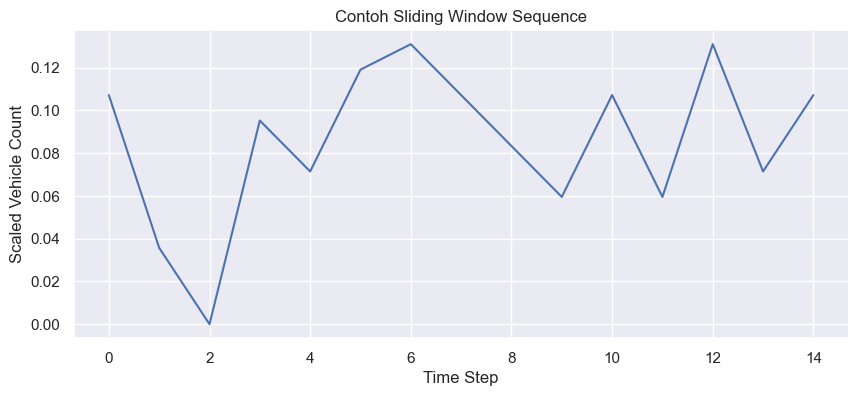

In [41]:
# VISUALISASI CONTOH SLIDING WINDOW #
plt.figure(figsize=(10,4))

# Feature index 0 = vehicle_count_1min
plt.plot(X_train_3d[0][:, 0])
plt.title('Contoh Sliding Window Sequence')
plt.xlabel('Time Step')
plt.ylabel('Scaled Vehicle Count')
plt.grid(True)
plt.show()

# **Penyimpanan Dataset Hasil Preprocessing**

In [42]:
# MENYIMPAN DATA TENSOR # -> Mempermudah loading data saat training model
os.makedirs('data_clean', exist_ok=True)

np.save(
    'data_clean/X_train_lstm.npy',
    X_train_3d
)

np.save(
    'data_clean/y_train_lstm.npy',
    y_train_3d
)

np.save(
    'data_clean/X_test_lstm.npy',
    X_test_3d
)

np.save(
    'data_clean/y_test_lstm.npy',
    y_test_3d
)

print(
    "\n[SUCCESS] Tensor dataset berhasil disimpan."
)

# MENYIMPAN METADATA TENSOR # -> untuk deployment dan inference
tensor_metadata = {
    'TIME_STEPS': TIME_STEPS,
    'NUM_FEATURES': X_train_3d.shape[2],
    'TRAIN_SHAPE': X_train_3d.shape,
    'TEST_SHAPE': X_test_3d.shape
}

joblib.dump(
    tensor_metadata,
    'data_clean/tensor_metadata.pkl'
)

print("[SUCCESS] Metadata tensor berhasil disimpan.")


[SUCCESS] Tensor dataset berhasil disimpan.
[SUCCESS] Metadata tensor berhasil disimpan.


In [43]:
# VERIFIKASI FILE TERSIMPAN #
print("\nISI FOLDER data_clean")
print(os.listdir('data_clean'))

# VERIFIKASI FINAL PIPELINE #
print("\n[INFO] Sliding window & tensor preparation selesai.")
print(
    f"\nFinal shape training tensor : "
    f"{X_train_3d.shape}"
)

print(
    f"Final shape testing tensor  : "
    f"{X_test_3d.shape}"
)


ISI FOLDER data_clean
['tensor_metadata.pkl', 'X_test_lstm.npy', 'X_train_lstm.npy', 'y_test_lstm.npy', 'y_train_lstm.npy']

[INFO] Sliding window & tensor preparation selesai.

Final shape training tensor : (32229, 15, 33)
Final shape testing tensor  : (8047, 15, 33)
